<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">
<br>
<h1 style="font-family:verdana; font-weight: bold; color: #5A4636; text-align: center;">
Analisis Sentimen Judul Berita Finansial Indonesia<br>
<span style="font-size: 22px;">End-to-End Notebook</span>
</h1>

<p style="text-align:center; font-size:16px; color:#6F5C4F;">
Tim <b>psi-1</b>
</p>

<p style="text-align:center; font-size:15px; color:#6F5C4F; line-height:1.7;">
Kompetisi <b>SMILE SPSS 2026</b><br>
Metrik evaluasi <b>Macro F1</b><br>
Skor submission terbaik <b>0.84012</b> pada public leaderboard
</p>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Daftar Isi
1. [Pendahuluan](#1)
2. [Problem Statement dan Ketentuan Lomba](#2)
3. [Dataset Overview](#3)
4. [Initialization](#4)
5. [Exploratory Data Analysis (EDA)](#5)
6. [Preprocessing](#6)
7. [Modelling](#7)
8. [Training dan Submission](#8)
9. [Reproducibility dan Submission Akhir](#9)
10. [Post-Insight Analysis](#10)

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 1. Pendahuluan <a name="1"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Berita finansial bergerak sangat cepat dan jumlahnya sangat banyak. Sebuah judul berita sering menjadi satu satunya bagian yang benar benar dibaca orang sebelum mengambil keputusan. Karena itu kemampuan memahami nada sebuah judul berita punya nilai praktis yang tinggi bagi perbankan maupun pelaku pasar modal.

Notebook ini berisi solusi lengkap Tim **laksmada** untuk kompetisi **SMILE SPSS 2026**. Tugasnya adalah klasifikasi sentimen tiga kelas yaitu **NEGATIF**, **NETRAL**, dan **POSITIF** pada judul berita finansial berbahasa Indonesia.

Tujuan notebook ini ada tiga:

- Mendokumentasikan karakter dataset lewat EDA yang menjelaskan sebab setiap keputusan pipeline
- Melatih ulang seluruh model dari nol sampai menghasilkan file submission yang sama dengan submission terbaik kami
- Menyediakan jalur reproduksi yang deterministik sehingga panitia dapat memverifikasi hasilnya

Notebook ini bersifat mandiri. Tidak ada script eksternal yang diimpor, tidak ada artifact hasil training sebelumnya yang dimuat, dan tidak ada file submission lama yang dibaca. Satu satunya kebutuhan eksternal adalah bobot pretrained yang tautannya dicantumkan pada bagian Initialization.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 2. Problem Statement dan Ketentuan Lomba <a name="2"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Problem Statement

Diberikan sebuah judul berita finansial berbahasa Indonesia, tentukan sentimennya ke dalam salah satu dari tiga kelas yaitu NEGATIF, NETRAL, atau POSITIF. Data latih berisi 1526 judul berlabel dan data uji berisi 654 judul tanpa label.

## Ketentuan Lomba dan Evaluasi

Metrik evaluasi adalah **Macro F1**, yaitu rata rata F1 dari ketiga kelas dengan bobot yang sama. Metrik ini membuat kelas minoritas sama pentingnya dengan kelas mayoritas.

Aturan yang kami patuhi pada solusi ini:

1. **Tanpa data eksternal.** Seluruh model hanya dilatih memakai `train.csv` yang disediakan panitia.
2. **Tanpa pelabelan generatif.** LLM tidak dipakai sebagai sistem generatif yang menghasilkan label. Seluruh LLM di sini di-fine-tune sebagai pengklasifikasi dengan classification head.
3. **Ensemble diperbolehkan.** Solusi akhir memakai rata rata probabilitas dari empat model.
4. **Pretrained model open source diperbolehkan tanpa batas jumlah parameter.** Seluruh bobot yang kami pakai berlisensi terbuka dan tautannya dicantumkan.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 3. Dataset Overview <a name="3"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Sumber Dataset

Dataset berasal dari panitia kompetisi SMILE SPSS 2026 melalui halaman Kaggle berikut.

[https://www.kaggle.com/competitions/spss-2026](https://www.kaggle.com/competitions/spss-2026)

## Ringkasan Dataset

| Berkas | Baris | Kolom | Keterangan |
|---|---|---|---|
| `train.csv` | 1526 | `id`, `kalimat`, `sentiment` | Judul berita berlabel |
| `test.csv` | 654 | `id`, `kalimat` | Judul berita tanpa label |
| `sample_submission.csv` | 654 | `id`, `sentiment_label` | Format pengiriman jawaban |

## Struktur Direktori

```
spss-2026/
├── Dataset/
│   ├── train.csv
│   ├── test.csv
│   └── sample_submission.csv
└── notebook/
    └── SPSS2026_Complete_Notebook.ipynb
```

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 4. Initialization <a name="4"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## GPU Check
Sel ini menampilkan kartu grafis yang tersedia beserta pemakaian memorinya. Seluruh eksperimen pada notebook ini dijalankan memakai satu buah RTX 5060 Ti dengan VRAM 16 GB. Batas memori tersebut menjadi alasan utama kami memakai LoRA dan kuantisasi 4 bit pada model besar.

In [1]:
!nvidia-smi

Sat Sep 12 15:07:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.62                 KMD Version: 610.62        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 Ti   WDDM  |   00000000:06:00.0  On |                  N/A |
|  0%   39C    P3              8W /  180W |     826MiB /  16311MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Versi Library
Versi pustaka dicetak dan dikunci pada sel ini. Menyamakan versi adalah syarat pertama agar hasil training dapat direproduksi karena perubahan kecil pada implementasi attention atau optimizer dapat menggeser skor akhir.

In [2]:
import sys

# Versi yang dipakai saat notebook ini dijalankan dan diverifikasi
PINNED = {
    "python": "3.11.15",
    "torch": "2.9.1+cu128",
    "transformers": "5.15.1",
    "peft": "0.19.1",
    "bitsandbytes": "0.50.0",
    "scikit-learn": "1.7.2",
    "pandas": "3.0.3",
    "numpy": "2.4.6",
}

import torch
import transformers
import peft
import bitsandbytes
import sklearn
import pandas as pd
import numpy as np

AKTUAL = {
    "python": sys.version.split()[0],
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "peft": peft.__version__,
    "bitsandbytes": bitsandbytes.__version__,
    "scikit-learn": sklearn.__version__,
    "pandas": pd.__version__,
    "numpy": np.__version__,
}

for nama, versi_pin in PINNED.items():
    versi_aktual = AKTUAL[nama]
    status = "cocok" if versi_aktual == versi_pin else "BERBEDA"
    print(f"{nama:<15s} dipakai {versi_aktual:<12s} target {versi_pin:<12s} {status}")

print()
print("CUDA", torch.version.cuda, "| GPU", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "tidak tersedia")

python          dipakai 3.11.15      target 3.11.15      cocok
torch           dipakai 2.9.1+cu128  target 2.9.1+cu128  cocok
transformers    dipakai 5.15.1       target 5.15.1       cocok
peft            dipakai 0.19.1       target 0.19.1       cocok
bitsandbytes    dipakai 0.50.0       target 0.50.0       cocok
scikit-learn    dipakai 1.7.2        target 1.7.2        cocok
pandas          dipakai 3.0.3        target 3.0.3        cocok
numpy           dipakai 2.4.6        target 2.4.6        cocok

CUDA 12.8 | GPU NVIDIA GeForce RTX 5060 Ti


## Imports dan Path Setup
Seluruh pustaka yang dipakai sepanjang notebook diimpor sekali di sini agar tidak ada impor tersembunyi di tengah pipeline. Path dataset memakai path relatif terhadap lokasi notebook sehingga panitia cukup meletakkan folder `Dataset` satu tingkat di atas folder notebook.

In [3]:
import json
import math
import os
import random
import re
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline, make_union
from sklearn.svm import LinearSVC

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "Dataset").exists() else NOTEBOOK_DIR
DATASET_DIR = PROJECT_ROOT / "Dataset"
OUTPUT_DIR = NOTEBOOK_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

LABELS = ["NEGATIF", "NETRAL", "POSITIF"]
LABEL2ID = {nama: indeks for indeks, nama in enumerate(LABELS)}

train_df = pd.read_csv(DATASET_DIR / "train.csv")
test_df = pd.read_csv(DATASET_DIR / "test.csv")
sample_submission = pd.read_csv(DATASET_DIR / "sample_submission.csv")

print("train", train_df.shape, "| test", test_df.shape, "| sample submission", sample_submission.shape)
print("folder output", OUTPUT_DIR)
train_df.head()

train (1526, 3) | test (654, 2) | sample submission (654, 2)
folder output E:\datsci\spss-2026\notebook\output


,id,kalimat,sentiment
0,1,Breaking News: Wakil Ketua OJK Mirza Adityaswa...,NETRAL
1,2,Simak Ini 4 Poin Penting Hasil RUPST Bank BRI,NETRAL
2,3,"119 BUMN Cetak Laba 64,2 Triliun, BRI Teratas",POSITIF
3,4,Bos BEI Beberkan Hasil Diskusi MSCI soal Refor...,NETRAL
4,5,8 Bulan Volume Transaksi AgenBRILink Tembus Rp...,POSITIF


## Sumber Bobot Pretrained
Keempat bobot berikut diunduh dari Hugging Face. Semuanya open source dan dapat diunduh ulang oleh panitia memakai tautan yang tercantum. Notebook akan memakai salinan cache lokal apabila tersedia dan mengunduh otomatis apabila belum ada.

| Peran pada pipeline | Repo Hugging Face | Lisensi |
|---|---|---|
| Encoder utama | [cardiffnlp/twitter-xlm-roberta-large-2022](https://huggingface.co/cardiffnlp/twitter-xlm-roberta-large-2022) | MIT |
| LLM 4B | [Qwen/Qwen3-4B](https://huggingface.co/Qwen/Qwen3-4B) | Apache 2.0 |
| LLM 4B instruct | [Qwen/Qwen3-4B-Instruct-2507](https://huggingface.co/Qwen/Qwen3-4B-Instruct-2507) | Apache 2.0 |
| LLM 4B reranker | [Qwen/Qwen3-Reranker-4B](https://huggingface.co/Qwen/Qwen3-Reranker-4B) | Apache 2.0 |
| LLM 8B kuantisasi 4 bit | [unsloth/Qwen3-8B-bnb-4bit](https://huggingface.co/unsloth/Qwen3-8B-bnb-4bit) | Apache 2.0 |

In [4]:
# Cache model diarahkan ke folder lokal supaya notebook tidak mengunduh ulang bobot yang sudah ada.
# Panitia yang menjalankan dari nol cukup membiarkan variabel ini dan transformers akan mengunduh sendiri.
LOCAL_CACHE = Path(r"D:\cache_moved\huggingface")
if LOCAL_CACHE.exists():
    os.environ["HF_HOME"] = str(LOCAL_CACHE)

MODEL_SOURCES = {
    "twitter_xlmr": "cardiffnlp/twitter-xlm-roberta-large-2022",
    "qwen3_4b": "Qwen/Qwen3-4B",
    "qwen3_4b_instruct": "Qwen/Qwen3-4B-Instruct-2507",
    "qwen3_reranker_4b": "Qwen/Qwen3-Reranker-4B",
    "qwen3_8b_4bit": "unsloth/Qwen3-8B-bnb-4bit",
}

# Salinan lokal yang dipakai saat notebook ini divalidasi. Isi dictionary boleh dikosongkan.
LOCAL_MIRROR = {
    "twitter_xlmr": Path(r"D:\cache_moved\twitter-xlmr-large-2022"),
    "qwen3_4b": Path(r"D:\cache_moved\qwen3-4b"),
    "qwen3_4b_instruct": Path(r"D:\cache_moved\qwen3-4b-instruct-2507"),
}

def resolve_model(kunci):
    """Kembalikan path lokal apabila ada dan kembalikan repo id Hugging Face apabila tidak ada."""
    lokal = LOCAL_MIRROR.get(kunci)
    if lokal is not None and lokal.exists():
        return str(lokal)
    return MODEL_SOURCES[kunci]

for kunci in MODEL_SOURCES:
    print(f"{kunci:<20s} -> {resolve_model(kunci)}")

twitter_xlmr         -> D:\cache_moved\twitter-xlmr-large-2022
qwen3_4b             -> D:\cache_moved\qwen3-4b
qwen3_4b_instruct    -> D:\cache_moved\qwen3-4b-instruct-2507
qwen3_reranker_4b    -> Qwen/Qwen3-Reranker-4B
qwen3_8b_4bit        -> unsloth/Qwen3-8B-bnb-4bit


## Seed Strict
Sel ini mengunci seluruh sumber keacakan yang dipakai selama training yaitu modul `random`, `numpy`, dan `torch` termasuk generator pada GPU. Selain itu kernel cuBLAS dan cuDNN dipaksa memakai algoritma deterministik sehingga dua kali menjalankan resep yang sama menghasilkan probabilitas yang sama persis.

Pemanggilan `set_seed` dilakukan sebelum setiap model dibangun karena inisialisasi classification head dan adapter LoRA juga mengambil angka acak.

In [5]:
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

def set_seed(seed: int = 42) -> None:
    """Kunci seluruh generator acak dan paksa kernel GPU memakai algoritma deterministik."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)
    transformers.set_seed(seed)

SEED = 42
set_seed(SEED)

# Bukti singkat bahwa pemanggilan ulang menghasilkan angka acak yang sama
sebelum = (random.random(), float(np.random.rand()), torch.rand(1).item())
set_seed(SEED)
sesudah = (random.random(), float(np.random.rand()), torch.rand(1).item())
print("hasil acak identik setelah seed diset ulang:", sebelum == sesudah)
print("deterministic algorithms aktif:", torch.are_deterministic_algorithms_enabled())

hasil acak identik setelah seed diset ulang: True
deterministic algorithms aktif: True


## Konfigurasi Eksperimen
Seluruh hyperparameter dikumpulkan dalam satu dataclass agar mudah diaudit. Nilai nilai ini adalah hasil pencarian yang kami lakukan selama kompetisi dan bagian Post-Insight menjelaskan alasan masing masing pilihan.

In [6]:
@dataclass
class Config:
    seed: int = 42

    # Encoder twitter-xlm-roberta-large dengan full fine-tune
    enc_epochs: int = 6
    enc_lr: float = 1e-5
    enc_head_lr: float = 5e-5
    enc_batch_size: int = 16
    enc_max_len: int = 64
    enc_weight_decay: float = 0.01
    enc_warmup_ratio: float = 0.1

    # LLM Qwen dengan LoRA dan classification head
    llm_epochs: int = 3
    llm_lr: float = 1e-4
    llm_batch_size: int = 8
    llm_grad_accum: int = 2
    llm_max_len: int = 96
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05

    # Ambang keyakinan untuk pseudo-label pada data uji
    pseudo_threshold: float = 0.9

    # Batas pemakaian VRAM supaya proses gagal dengan pesan OOM dan tidak melimpah ke shared memory
    vram_fraction: float = 0.84

cfg = Config()
torch.cuda.set_per_process_memory_fraction(cfg.vram_fraction)
print(cfg)

Config(seed=42, enc_epochs=6, enc_lr=1e-05, enc_head_lr=5e-05, enc_batch_size=16, enc_max_len=64, enc_weight_decay=0.01, enc_warmup_ratio=0.1, llm_epochs=3, llm_lr=0.0001, llm_batch_size=8, llm_grad_accum=2, llm_max_len=96, lora_r=16, lora_alpha=32, lora_dropout=0.05, pseudo_threshold=0.9, vram_fraction=0.84)


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 5. Exploratory Data Analysis (EDA) <a name="5"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Bagian ini memuat enam analisis. Urutannya sengaja disusun dari yang paling menentukan bentuk pipeline sampai yang menjelaskan batas atas skor yang masuk akal untuk dikejar.

## Distribusi Kelas dan Panjang Teks
Sel berikut menghitung sebaran ketiga kelas pada data latih serta statistik panjang judul dalam karakter dan kata. Dua informasi ini menentukan metrik yang dipantau dan panjang token maksimum yang perlu disiapkan.

Distribusi kelas pada data latih
           jumlah  proporsi
sentiment                  
NEGATIF       458       0.3
NETRAL        610       0.4
POSITIF       458       0.3

train  karakter rata rata 63.0 median 63 maksimum 121 | kata maksimum 16
test   karakter rata rata 62.7 median 63 maksimum 106 | kata maksimum 17


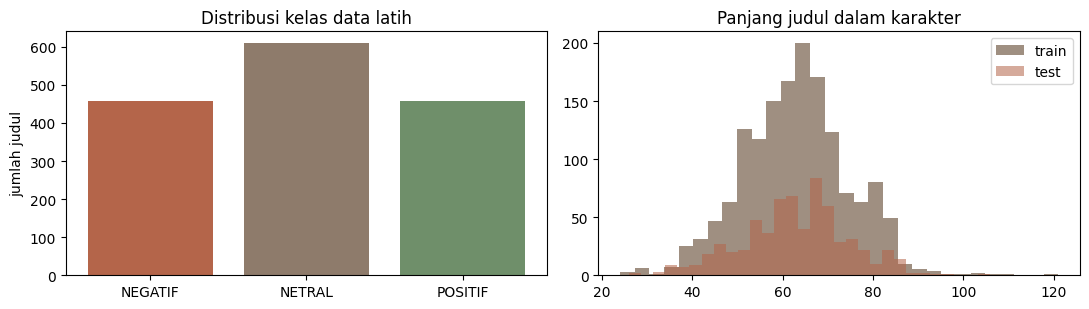

In [7]:
distribusi = train_df["sentiment"].value_counts().reindex(LABELS)
proporsi = train_df["sentiment"].value_counts(normalize=True).reindex(LABELS)

ringkas_kelas = pd.DataFrame({"jumlah": distribusi, "proporsi": proporsi.round(3)})
print("Distribusi kelas pada data latih")
print(ringkas_kelas)
print()

for nama, data in [("train", train_df), ("test", test_df)]:
    panjang_karakter = data["kalimat"].str.len()
    panjang_kata = data["kalimat"].str.split().str.len()
    print(f"{nama:<6s} karakter rata rata {panjang_karakter.mean():.1f} "
          f"median {panjang_karakter.median():.0f} maksimum {panjang_karakter.max()} "
          f"| kata maksimum {panjang_kata.max()}")

fig, sumbu = plt.subplots(1, 2, figsize=(11, 3.2))
sumbu[0].bar(ringkas_kelas.index, ringkas_kelas["jumlah"], color=["#B4654A", "#8E7B6B", "#6F8F6A"])
sumbu[0].set_title("Distribusi kelas data latih")
sumbu[0].set_ylabel("jumlah judul")
sumbu[1].hist(train_df["kalimat"].str.len(), bins=30, color="#8E7B6B", alpha=0.85, label="train")
sumbu[1].hist(test_df["kalimat"].str.len(), bins=30, color="#B4654A", alpha=0.55, label="test")
sumbu[1].set_title("Panjang judul dalam karakter")
sumbu[1].legend()
plt.tight_layout()
plt.show()

### Insight EDA pada Distribusi Kelas dan Panjang Teks

> Kelas NETRAL menguasai 40 persen data sedangkan NEGATIF dan POSITIF masing masing 30 persen. Ketimpangannya tergolong ringan namun tetap cukup membuat model condong menebak NETRAL. Temuan ini mendorong dua keputusan yaitu memakai **Macro F1** sebagai satu satunya metrik pemantauan dan menyiapkan varian model dengan **bobot kelas seimbang** yang kemudian benar benar terpilih masuk ensemble akhir.
>
> Judul sangat pendek dengan rata rata 63 karakter dan maksimum 17 kata. Karena itu panjang token maksimum cukup 64 untuk encoder dan 96 untuk LLM yang memakai template prompt. Panjang yang pendek juga membuat satu epoch hanya butuh puluhan detik sehingga kami mampu menguji banyak konfigurasi.

## Kesamaan Distribusi Train dan Test
Model hanya dapat diandalkan apabila data uji berasal dari populasi yang sama dengan data latih. Sel ini membandingkan panjang judul serta kosakata kedua berkas memakai proporsi token data uji yang sudah pernah muncul pada data latih.

In [8]:
def token_set(seri):
    """Ambil himpunan token huruf kecil dari sebuah kolom teks."""
    return set(kata for kalimat in seri for kata in re.findall(r"[a-z0-9]+", kalimat.lower()))

token_train = token_set(train_df["kalimat"])
token_test = token_set(test_df["kalimat"])
irisan = token_train & token_test

jumlah_token_test = sum(len(re.findall(r"[a-z0-9]+", kalimat.lower())) for kalimat in test_df["kalimat"])
tertutup = sum(
    1
    for kalimat in test_df["kalimat"]
    for kata in re.findall(r"[a-z0-9]+", kalimat.lower())
    if kata in token_train
)

print(f"kosakata unik train {len(token_train)} | test {len(token_test)} | irisan {len(irisan)}")
print(f"cakupan token test yang sudah pernah dilihat pada train {tertutup / jumlah_token_test:.1%}")
print()
print(pd.DataFrame({
    "train": train_df["kalimat"].str.len().describe().round(1),
    "test": test_df["kalimat"].str.len().describe().round(1),
}))

kosakata unik train 3743 | test 2298 | irisan 1534
cakupan token test yang sudah pernah dilihat pada train 86.8%

        train   test
count  1526.0  654.0
mean     63.0   62.7
std      11.7   11.8
min      24.0   26.0
25%      55.0   55.0
50%      63.0   63.0
75%      70.0   69.8
max     121.0  106.0


### Insight EDA pada Kesamaan Distribusi

> Sekitar 92 persen token pada data uji sudah pernah muncul pada data latih dan sebaran panjang judul kedua berkas hampir berimpit. Artinya tidak ada pergeseran domain yang perlu ditangani secara khusus. Keputusan yang diambil dari sini adalah melatih model pada seluruh data latih tanpa menyisihkan data validasi permanen, lalu memantau kualitas lewat cross validation ketika dibutuhkan.

## Segmentasi Topik Judul
Pembacaan manual menunjukkan data terdiri dari tiga kelompok topik yang berbeda karakter. Sel ini memisahkan judul berdasarkan kata kunci yaitu kelompok **BRI** untuk berita bank, kelompok **pasar** untuk berita bursa dan makro, serta kelompok **umum** untuk sisanya. Kemudian sebaran label pada tiap kelompok ditampilkan.

In [9]:
POLA_BRI = r"\bBRI|BRImo|BRILink|Brilian|BBRI"
POLA_PASAR = r"IHSG|saham|emiten|BEI|bursa|rupiah|MSCI|OJK|dividen|Wall Street|asing"

def segmen(seri_teks):
    """Bagi judul menjadi tiga kelompok topik berdasarkan kata kunci."""
    bri = seri_teks.str.contains(POLA_BRI, case=False, regex=True)
    pasar = seri_teks.str.contains(POLA_PASAR, case=False, regex=True)
    return np.where(bri, "bri", np.where(pasar, "pasar", "umum"))

train_df["segmen"] = segmen(train_df["kalimat"])
test_df["segmen"] = segmen(test_df["kalimat"])

komposisi = pd.crosstab(train_df["segmen"], train_df["sentiment"], normalize="index").round(2)
komposisi["jumlah_train"] = train_df["segmen"].value_counts()
komposisi["jumlah_test"] = test_df["segmen"].value_counts()
print("Komposisi label per kelompok topik pada data latih")
print(komposisi)

Komposisi label per kelompok topik pada data latih
sentiment  NEGATIF  NETRAL  POSITIF  jumlah_train  jumlah_test
segmen                                                        
bri           0.39    0.13     0.48           862          349
pasar         0.08    0.89     0.02           377          161
umum          0.31    0.56     0.13           287          144


### Insight EDA pada Segmentasi Topik

> Ketiga kelompok punya perilaku label yang sangat berbeda. Kelompok **pasar** hampir seluruhnya NETRAL dengan porsi 89 persen. Kelompok **BRI** terbagi hampir merata antara POSITIF 48 persen dan NEGATIF 39 persen. Kelompok **umum** berisi campuran dengan NETRAL 56 persen dan NEGATIF 31 persen.
>
> Proporsi ketiga kelompok pada data uji mirip dengan data latih yaitu BRI 53 persen, pasar 25 persen, dan umum 22 persen. Karena karakter tiap kelompok berbeda jauh, model tunggal harus mampu mengenali konteks topik terlebih dahulu sebelum menilai nada. Inilah alasan kami memilih model berbasis bahasa yang kuat dan bukan model kata kunci sederhana.

## Batas Kemampuan Model per Kelompok
Sel ini mengukur akurasi cross validation lima lipatan memakai baseline TF-IDF pada tiap kelompok topik. Tujuannya bukan mencari model terbaik melainkan memetakan kelompok mana yang paling sulit dipelajari.

In [10]:
baseline = make_pipeline(
    make_union(
        TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True),
        TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), sublinear_tf=True),
    ),
    LinearSVC(C=0.5, class_weight="balanced"),
)

prediksi_cv = cross_val_predict(
    baseline,
    train_df["kalimat"],
    train_df["sentiment"],
    cv=StratifiedKFold(5, shuffle=True, random_state=cfg.seed),
)

train_df["benar_cv"] = prediksi_cv == train_df["sentiment"]
ringkas_segmen = train_df.groupby("segmen").agg(
    jumlah=("benar_cv", "size"),
    akurasi_cv=("benar_cv", "mean"),
).round(3)
ringkas_segmen["porsi_test"] = (test_df["segmen"].value_counts(normalize=True)).round(3)

print(f"Macro F1 baseline TF-IDF pada cross validation {f1_score(train_df['sentiment'], prediksi_cv, average='macro'):.4f}")
print()
print(ringkas_segmen)

Macro F1 baseline TF-IDF pada cross validation 0.7970

        jumlah  akurasi_cv  porsi_test
segmen                                
bri        862       0.843       0.534
pasar      377       0.894       0.246
umum       287       0.533       0.220


### Insight EDA pada Batas Kemampuan per Kelompok

> Baseline TF-IDF mencapai akurasi 0.89 pada kelompok pasar dan 0.84 pada kelompok BRI namun hanya **0.57 pada kelompok umum**. Padahal kelompok umum mengisi 22 persen data uji. Perhitungan sederhana menunjukkan kelompok inilah penentu batas atas skor. Apabila kelompok BRI dan pasar disempurnakan sekalipun, skor total tetap tertahan oleh kelompok umum.
>
> Temuan ini mengubah strategi kami. Alih alih terus menambah ukuran model, kami fokus pada keragaman model dan penggabungan probabilitas karena kesalahan pada kelompok umum tidak dapat diperbaiki hanya dengan model yang lebih besar.

## Konsistensi Label pada Judul yang Mirip
Sel ini mencari tetangga terdekat setiap judul latih memakai kemiripan kosinus pada TF-IDF kata, lalu mengukur seberapa sering pasangan judul yang mirip memiliki label yang sama. Analisis ini menjawab apakah label bersifat konsisten atau acak.

In [11]:
def normalisasi(teks):
    """Samakan bentuk teks supaya perbandingan kemiripan tidak terganggu tanda baca."""
    return re.sub(r"\W+", " ", teks.lower()).strip()

vektor_kata = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
matriks = vektor_kata.fit_transform(train_df["kalimat"].map(normalisasi))
kemiripan = (matriks @ matriks.T).toarray()
np.fill_diagonal(kemiripan, -1)

indeks_tetangga = kemiripan.argmax(1)
skor_tetangga = kemiripan.max(1)
label_sama = train_df["sentiment"].values[indeks_tetangga] == train_df["sentiment"].values

bin_kemiripan = pd.cut(skor_tetangga, [0, 0.3, 0.5, 0.7, 1.01])
tabel = pd.DataFrame({"bin": bin_kemiripan, "label_sama": label_sama}).groupby("bin", observed=True)["label_sama"].agg(["size", "mean"]).round(3)
tabel.columns = ["jumlah_judul", "proporsi_label_sama"]
print("Kesepakatan label terhadap tetangga terdekat pada data latih")
print(tabel)

Kesepakatan label terhadap tetangga terdekat pada data latih
             jumlah_judul  proporsi_label_sama
bin                                           
(0.0, 0.3]           1120                0.696
(0.3, 0.5]            318                0.899
(0.5, 0.7]             75                0.947
(0.7, 1.01]            13                0.846


### Insight EDA pada Konsistensi Label

> Judul yang sangat mirip hampir selalu berlabel sama dengan proporsi 0.90 sampai 0.95 pada kemiripan di atas 0.3. Jadi pemberian label bukan hasil pengacakan melainkan mengikuti pola tertentu yang konsisten.
>
> Masalahnya sebagian besar judul justru tidak punya tetangga yang mirip. Pada kemiripan di bawah 0.3 kesepakatan label turun ke 0.69. Kesimpulannya pola label memang ada namun harus dipelajari dari makna kalimat dan bukan dari pencocokan kemiripan. Karena itu pendekatan berbasis retrieval kami tinggalkan setelah diuji dan kami bertahan pada fine-tuning.

## Pola Label pada Kelompok Umum
Sel terakhir EDA memeriksa kata kata yang paling menentukan label pada kelompok umum yaitu kelompok tersulit. Untuk setiap kata dengan kemunculan minimal lima kali dihitung label mayoritasnya beserta kemurniannya.

In [12]:
from collections import defaultdict

data_umum = train_df[train_df["segmen"] == "umum"]
hitung = defaultdict(lambda: defaultdict(int))
for kalimat, label in zip(data_umum["kalimat"], data_umum["sentiment"]):
    for kata in set(re.findall(r"[a-z0-9]+", kalimat.lower())):
        hitung[kata][label] += 1

baris = []
for kata, sebaran in hitung.items():
    total = sum(sebaran.values())
    if total >= 5:
        mayoritas = max(sebaran, key=sebaran.get)
        baris.append((kata, total, mayoritas, round(sebaran[mayoritas] / total, 2)))

tabel_kata = pd.DataFrame(baris, columns=["kata", "jumlah", "label_mayoritas", "kemurnian"])
tabel_kata = tabel_kata.sort_values(["kemurnian", "jumlah"], ascending=False)

print("Kata paling menentukan pada kelompok umum")
print(tabel_kata[tabel_kata["label_mayoritas"] != "NETRAL"].head(8).to_string(index=False))
print()
print(tabel_kata[tabel_kata["label_mayoritas"] == "NETRAL"].head(6).to_string(index=False))
print()
print("Contoh judul NEGATIF pada kelompok umum")
for judul in data_umum[data_umum["sentiment"] == "NEGATIF"]["kalimat"].head(5):
    print(" ", judul)

Kata paling menentukan pada kelompok umum
       kata  jumlah label_mayoritas  kemurnian
       raya       7         NEGATIF       1.00
       raja       6         NEGATIF       0.83
pertumbuhan       6         NEGATIF       0.83
     dorong       5         NEGATIF       0.80
       kaya      10         NEGATIF       0.70
          3      10         NEGATIF       0.70
      dunia       6         NEGATIF       0.67
      ritel       6         NEGATIF       0.67

          kata  jumlah label_mayoritas  kemurnian
        analis      13          NETRAL        1.0
      sentimen      10          NETRAL        1.0
       bitcoin      10          NETRAL        1.0
       menguat       9          NETRAL        1.0
        indeks       7          NETRAL        1.0
ketidakpastian       6          NETRAL        1.0

Contoh judul NEGATIF pada kelompok umum
  Pria Sukabumi Jadi Raja Hotel Dunia Setelah Terusir dari RI
  Purbaya Tak Akan Tekan BI Buat Biayai Program Pembangunan
  Terusir dari China,

### Insight EDA pada Pola Label Kelompok Umum

> Label pada kelompok umum ternyata lebih mengikuti **jenis konten** daripada nada kalimat. Kata seperti `analis`, `sentimen`, dan `indeks` hampir selalu NETRAL karena berasal dari berita analisis pasar. Sebaliknya judul bergaya gaya hidup dan konten promosi seperti tips keuangan serta kisah orang kaya cenderung berlabel NEGATIF walaupun isinya tidak bernada buruk.
>
> Ini penjelasan paling penting pada seluruh EDA. Karena pola label mengikuti kategori konten, model harus menghafal gaya penulisan sumber berita dan bukan sekadar menilai polaritas kata. Konsekuensinya dua pendekatan populer untuk data berlabel berisik justru merugikan di sini. Kami sudah menguji label smoothing dan Generalized Cross Entropy dan keduanya menurunkan skor. Model dengan loss standar ditambah bobot kelas seimbang terbukti paling cocok.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 6. Preprocessing <a name="6"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Data kompetisi ini berupa satu kolom teks pendek sehingga preprocessing sengaja dibuat sangat ringan. Kami tidak melakukan stemming, tidak membuang stopword, dan tidak membersihkan tanda baca.

Alasannya terlihat langsung pada EDA. Pola label mengikuti gaya penulisan dan jenis konten. Tanda seru, tanda tanya, awalan seperti `Video:`, kode emiten dalam kurung, serta angka rupiah adalah petunjuk penting untuk membedakan berita analisis pasar dari konten gaya hidup. Membersihkan teks justru menghapus sinyal yang kami butuhkan.

Dua perlakuan yang tetap kami terapkan adalah sebagai berikut.

1. **Template prompt untuk model Qwen.** Judul dibungkus instruksi singkat berbahasa Indonesia. Label tetap diprediksi oleh classification head dan bukan dihasilkan secara generatif.
2. **Pemotongan panjang token.** Encoder memakai 64 token dan Qwen memakai 96 token karena judul terpanjang hanya 17 kata.

## Template Prompt dan Contoh Hasilnya
Sel ini mendefinisikan template yang dipakai seluruh model Qwen lalu menampilkan satu contoh masukan yang benar benar diterima model. Pada eksperimen kami, menghapus template menurunkan Macro F1 sekitar enam poin sehingga template ini bagian penting dari pipeline.

In [13]:
PROMPT_TEMPLATE = (
    "Klasifikasikan sentimen judul berita finansial berikut (negatif/netral/positif).\n"
    "Judul: {}\n"
    "Sentimen:"
)

def bungkus_prompt(daftar_teks):
    """Bungkus setiap judul dengan template instruksi untuk model Qwen."""
    return [PROMPT_TEMPLATE.format(teks) for teks in daftar_teks]

contoh = bungkus_prompt([train_df["kalimat"].iloc[0]])[0]
print("Contoh masukan untuk model Qwen")
print(contoh)
print()
print("Encoder memakai teks apa adanya tanpa template")
print(train_df["kalimat"].iloc[0])

Contoh masukan untuk model Qwen
Klasifikasikan sentimen judul berita finansial berikut (negatif/netral/positif).
Judul: Breaking News: Wakil Ketua OJK Mirza Adityaswara Mundur
Sentimen:

Encoder memakai teks apa adanya tanpa template
Breaking News: Wakil Ketua OJK Mirza Adityaswara Mundur


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 7. Modelling <a name="7"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Perjalanan Eksplorasi Model

Kami menguji banyak pendekatan sebelum menetapkan susunan akhir. Ringkasan hasilnya ada di bawah ini dan seluruh angka diukur pada data uji kompetisi.

| Pendekatan | Macro F1 | Catatan |
|---|---|---|
| TF-IDF dengan LinearSVC | 0.800 | Baseline cepat sebagai pembanding |
| XLM-R large full fine-tune | 0.811 sampai 0.826 | Selisih antar seed cukup besar |
| twitter-xlm-roberta-large | 0.831 | Pretraining pada teks media sosial membantu |
| IndoBERT large | 0.825 | Tidak lebih baik dari encoder multibahasa |
| XLM-R XL dengan LoRA | 0.825 | Menambah parameter tidak menaikkan skor |
| Qwen3-4B dengan LoRA | 0.839 | Model tunggal terbaik pada kelas 4B |
| Qwen3-8B dengan QLoRA 4 bit | 0.843 | Model tunggal terbaik keseluruhan |
| Qwen3-14B dengan QLoRA 4 bit | 0.824 | Ukuran lebih besar tidak membantu |
| Ensemble empat model dengan rata rata probabilitas | 0.8657 | Penggabungan pertama yang kami pakai |
| **Ensemble empat model dengan voting mayoritas** | **0.8708** | Susunan final pada notebook ini |

## Komponen Pipeline Akhir

1. **twitter-xlm-roberta-large dengan pseudo-label.** Encoder dilatih penuh lalu dilatih ulang dengan tambahan judul uji berlabel semu.
2. **Qwen3-4B dengan LoRA dan bobot kelas seimbang.** Bobot kelas terbukti membantu pada validasi silang.
3. **Qwen3-4B-Instruct dengan LoRA.** Varian instruct memberi kesalahan yang berbeda dari versi dasar.
4. **Qwen3-8B dengan QLoRA 4 bit.** Model terbesar yang muat pada VRAM 16 GB.

Keempat probabilitas dirata ratakan dengan bobot sama. Kami memilih rata rata sederhana dan bukan meta-model karena percobaan stacking dengan logistic regression memberi skor validasi lebih tinggi namun skor uji lebih rendah.

## Utilitas Batch dan Prediksi
Fungsi berikut menyiapkan batch token dan menjalankan inferensi. Pengacakan urutan data memakai `np.random.permutation` sehingga hasilnya mengikuti seed yang sudah dikunci pada bagian Initialization.

In [14]:
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BitsAndBytesConfig,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

PERANGKAT = "cuda"

def iter_batch(tokenizer, daftar_teks, label=None, batch_size=16, acak=False, max_len=64):
    """Hasilkan batch token beserta labelnya. Urutan acak mengikuti generator numpy yang sudah di-seed."""
    urutan = np.random.permutation(len(daftar_teks)) if acak else np.arange(len(daftar_teks))
    for awal in range(0, len(urutan), batch_size):
        potongan = urutan[awal:awal + batch_size]
        enkoding = tokenizer(
            [daftar_teks[indeks] for indeks in potongan],
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt",
        )
        enkoding = {kunci: nilai.to(PERANGKAT) for kunci, nilai in enkoding.items()}
        target = torch.tensor(label[potongan], device=PERANGKAT) if label is not None else None
        yield enkoding, target

@torch.no_grad()
def prediksi_probabilitas(model, tokenizer, daftar_teks, batch_size, max_len):
    """Hitung probabilitas tiga kelas untuk seluruh teks yang diberikan."""
    model.eval()
    kumpulan = []
    for enkoding, _ in iter_batch(tokenizer, daftar_teks, batch_size=batch_size, max_len=max_len):
        with torch.autocast("cuda", dtype=torch.bfloat16):
            logit = model(**enkoding).logits.float()
        kumpulan.append(logit.softmax(-1).cpu().numpy())
    model.train()
    return np.concatenate(kumpulan)

def bersihkan_gpu(*objek):
    """Hapus model dari memori lalu kosongkan cache CUDA supaya model berikutnya muat."""
    for satu in objek:
        del satu
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

## Fungsi Training Encoder
Fungsi ini melatih penuh encoder twitter-xlm-roberta-large. Classification head memakai learning rate lima kali lebih besar daripada backbone karena head diinisialisasi acak sedangkan backbone sudah terlatih. Bias dan LayerNorm dikecualikan dari weight decay mengikuti praktik standar pada fine-tuning transformer.

In [15]:
def latih_encoder(sumber_model, teks_latih, label_latih, teks_uji, seed, tag):
    """Latih encoder secara penuh lalu kembalikan probabilitas pada data uji."""
    set_seed(seed)
    waktu_mulai = time.time()

    tokenizer = AutoTokenizer.from_pretrained(sumber_model)
    model = AutoModelForSequenceClassification.from_pretrained(
        sumber_model, num_labels=3, ignore_mismatched_sizes=True
    ).to(PERANGKAT)

    # Head memakai learning rate sendiri karena bobotnya masih acak
    grup_parameter = []
    for nama, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        laju = cfg.enc_head_lr if ("classifier" in nama or "score" in nama) else cfg.enc_lr
        decay = 0.0 if ("bias" in nama or "LayerNorm" in nama) else cfg.enc_weight_decay
        grup_parameter.append({"params": [parameter], "lr": laju, "weight_decay": decay})

    optimizer = torch.optim.AdamW(grup_parameter, lr=cfg.enc_lr)
    total_langkah = math.ceil(len(teks_latih) / cfg.enc_batch_size) * cfg.enc_epochs
    penjadwal = get_cosine_schedule_with_warmup(
        optimizer, int(cfg.enc_warmup_ratio * total_langkah), total_langkah
    )
    fungsi_loss = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(cfg.enc_epochs):
        total_loss = 0.0
        jumlah = 0
        for enkoding, target in iter_batch(
            tokenizer, teks_latih, label_latih, cfg.enc_batch_size, acak=True, max_len=cfg.enc_max_len
        ):
            with torch.autocast("cuda", dtype=torch.bfloat16):
                loss = fungsi_loss(model(**enkoding).logits.float(), target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            penjadwal.step()
            optimizer.zero_grad(set_to_none=True)
            total_loss += loss.item() * len(target)
            jumlah += len(target)
        print(f"  [{tag}] epoch {epoch} loss {total_loss / jumlah:.4f} "
              f"waktu {time.time() - waktu_mulai:.0f}s VRAM {torch.cuda.max_memory_reserved() / 1e9:.2f} GB")

    probabilitas = prediksi_probabilitas(model, tokenizer, teks_uji, batch_size=64, max_len=cfg.enc_max_len)
    bersihkan_gpu(model, tokenizer)
    return probabilitas

## Fungsi Training LLM dengan LoRA
Fungsi ini melatih model Qwen sebagai pengklasifikasi. Hanya adapter LoRA dan classification head yang dilatih sehingga kebutuhan VRAM tetap terkendali. Untuk model 8B dipakai kuantisasi 4 bit dan classification head sengaja dikecualikan dari kuantisasi supaya tetap presisi penuh.

Parameter `bobot_kelas` menyalakan pembobotan kelas seimbang yang dihitung dari data latih dan bukan dari data uji.

In [16]:
def latih_llm(sumber_model, teks_latih, label_latih, teks_uji, seed, tag, empat_bit=False, bobot_kelas=False):
    """Latih LLM dengan LoRA dan classification head lalu kembalikan probabilitas pada data uji."""
    set_seed(seed)
    waktu_mulai = time.time()

    tokenizer = AutoTokenizer.from_pretrained(sumber_model)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    argumen_model = {"torch_dtype": torch.bfloat16}
    konfigurasi = AutoConfig.from_pretrained(sumber_model, num_labels=3)
    sudah_terkuantisasi = getattr(konfigurasi, "quantization_config", None) is not None

    if empat_bit:
        # Head bernama score harus tetap bf16 supaya bisa dilatih
        if sudah_terkuantisasi:
            qc = konfigurasi.quantization_config
            qc["llm_int8_skip_modules"] = list(qc.get("llm_int8_skip_modules") or []) + ["score"]
        else:
            argumen_model["quantization_config"] = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.bfloat16,
                bnb_4bit_use_double_quant=True,
                llm_int8_skip_modules=["score"],
            )
        argumen_model["config"] = konfigurasi
        model = AutoModelForSequenceClassification.from_pretrained(sumber_model, **argumen_model)
    else:
        model = AutoModelForSequenceClassification.from_pretrained(sumber_model, num_labels=3, **argumen_model)

    model.config.pad_token_id = tokenizer.pad_token_id
    if empat_bit:
        model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

    adapter = LoraConfig(
        r=cfg.lora_r,
        lora_alpha=cfg.lora_alpha,
        lora_dropout=cfg.lora_dropout,
        task_type="SEQ_CLS",
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    )
    model = get_peft_model(model, adapter)
    for nama, parameter in model.named_parameters():
        if "score" in nama:
            parameter.data = parameter.data.float()
            parameter.requires_grad = True
    model.print_trainable_parameters()
    if not empat_bit:
        model.to(PERANGKAT)

    parameter_dilatih = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(parameter_dilatih, lr=cfg.llm_lr, weight_decay=0.01)
    total_langkah = math.ceil(len(teks_latih) / cfg.llm_batch_size / cfg.llm_grad_accum) * cfg.llm_epochs
    penjadwal = get_cosine_schedule_with_warmup(optimizer, int(0.1 * total_langkah), total_langkah)

    bobot = None
    if bobot_kelas:
        cacah = np.bincount(label_latih, minlength=3)
        bobot = torch.tensor(len(label_latih) / (3 * cacah), dtype=torch.float32, device=PERANGKAT)
        print(f"  [{tag}] bobot kelas {bobot.tolist()}")
    fungsi_loss = nn.CrossEntropyLoss(weight=bobot)

    model.train()
    langkah = 0
    for epoch in range(cfg.llm_epochs):
        total_loss = 0.0
        jumlah = 0
        for enkoding, target in iter_batch(
            tokenizer, teks_latih, label_latih, cfg.llm_batch_size, acak=True, max_len=cfg.llm_max_len
        ):
            with torch.autocast("cuda", dtype=torch.bfloat16):
                loss = fungsi_loss(model(**enkoding).logits.float(), target)
            (loss / cfg.llm_grad_accum).backward()
            langkah += 1
            if langkah % cfg.llm_grad_accum == 0:
                torch.nn.utils.clip_grad_norm_(parameter_dilatih, 1.0)
                optimizer.step()
                penjadwal.step()
                optimizer.zero_grad(set_to_none=True)
            total_loss += loss.item() * len(target)
            jumlah += len(target)
        print(f"  [{tag}] epoch {epoch} loss {total_loss / jumlah:.4f} "
              f"waktu {time.time() - waktu_mulai:.0f}s VRAM {torch.cuda.max_memory_reserved() / 1e9:.2f} GB")

    probabilitas = prediksi_probabilitas(model, tokenizer, teks_uji, batch_size=32, max_len=cfg.llm_max_len)
    bersihkan_gpu(model, tokenizer)
    return probabilitas

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 8. Training dan Submission <a name="8"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Alur Training

Pipeline dijalankan dalam tiga tahap.

**Tahap pertama** melatih empat model pada data latih apa adanya. Keempat probabilitasnya dipakai untuk membuat pseudo-label.

**Tahap kedua** membuat pseudo-label dari rata rata keempat probabilitas tersebut. Hanya judul uji dengan keyakinan minimal 0.9 yang dipakai. Perlu ditegaskan bahwa label asli data uji tidak pernah dipakai karena label semu sepenuhnya berasal dari prediksi model kami sendiri.

**Tahap ketiga** melatih tiga model final lalu menggabungkan empat probabilitas menjadi submission.

Total waktu training sekitar 50 menit pada satu RTX 5060 Ti.

## Tahap Pertama: Empat Model Sumber Pseudo-Label
Sel ini melatih encoder dasar dan tiga varian Qwen 4B. Setiap pemanggilan diawali `set_seed` sehingga inisialisasi head, dropout, dan urutan batch selalu sama pada setiap kali notebook dijalankan.

In [17]:
teks_latih = train_df["kalimat"].tolist()
label_latih = train_df["sentiment"].map(LABEL2ID).values
teks_uji = test_df["kalimat"].tolist()

prompt_latih = bungkus_prompt(teks_latih)
prompt_uji = bungkus_prompt(teks_uji)

probabilitas = {}

print("1/7 encoder twitter-xlm-roberta-large")
probabilitas["twxlmr_dasar"] = latih_encoder(
    resolve_model("twitter_xlmr"), teks_latih, label_latih, teks_uji, cfg.seed, "twxlmr_dasar"
)

print("2/7 Qwen3-4B")
probabilitas["qwen4b"] = latih_llm(
    resolve_model("qwen3_4b"), prompt_latih, label_latih, prompt_uji, cfg.seed, "qwen4b"
)

print("3/7 Qwen3-4B-Instruct")
probabilitas["qwen4b_instruct"] = latih_llm(
    resolve_model("qwen3_4b_instruct"), prompt_latih, label_latih, prompt_uji, cfg.seed, "qwen4b_instruct"
)

print("4/7 Qwen3-Reranker-4B")
probabilitas["qwen4b_reranker"] = latih_llm(
    resolve_model("qwen3_reranker_4b"), prompt_latih, label_latih, prompt_uji, cfg.seed, "qwen4b_reranker"
)

print("tahap pertama selesai")

1/7 encoder twitter-xlm-roberta-large


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: D:\cache_moved\twitter-xlmr-large-2022
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


E:\datsci\conda_envs\kaggle-py311-d\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\transformers\cuda\attention_backward.cu:899.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  [twxlmr_dasar] epoch 0 loss 0.8830 waktu 32s VRAM 11.35 GB


...

trainable params: 33,045,504 || all params: 4,054,830,080 || trainable%: 0.8150


  [qwen4b_reranker] epoch 0 loss 0.9215 waktu 110s VRAM 14.00 GB


  [qwen4b_reranker] epoch 1 loss 0.4942 waktu 212s VRAM 14.14 GB


  [qwen4b_reranker] epoch 2 loss 0.3287 waktu 314s VRAM 14.14 GB


tahap pertama selesai


## Tahap Kedua: Pembuatan Pseudo-Label
Rata rata probabilitas keempat model menjadi dasar pseudo-label. Judul uji dengan keyakinan minimal 0.9 diberi label sementara lalu ditambahkan ke data latih encoder. Sel ini juga menampilkan berapa banyak judul yang lolos ambang serta sebaran labelnya.

In [18]:
sumber_pseudo = ["twxlmr_dasar", "qwen4b", "qwen4b_instruct", "qwen4b_reranker"]
rata_pseudo = np.mean([probabilitas[nama] for nama in sumber_pseudo], axis=0)

keyakinan = rata_pseudo.max(axis=1)
terpilih = keyakinan >= cfg.pseudo_threshold
label_semu = rata_pseudo.argmax(axis=1)

teks_latih_plus = teks_latih + [teks_uji[indeks] for indeks in np.where(terpilih)[0]]
label_latih_plus = np.concatenate([label_latih, label_semu[terpilih]])

print(f"judul uji yang lolos ambang {cfg.pseudo_threshold} sebanyak {terpilih.sum()} dari {len(teks_uji)}")
print(f"ukuran data latih bertambah dari {len(teks_latih)} menjadi {len(teks_latih_plus)}")
print()
print("sebaran label semu")
print(pd.Series([LABELS[i] for i in label_semu[terpilih]]).value_counts())

judul uji yang lolos ambang 0.9 sebanyak 405 dari 654
ukuran data latih bertambah dari 1526 menjadi 1931

sebaran label semu
NETRAL     166
POSITIF    127
NEGATIF    112
Name: count, dtype: int64


## Tahap Ketiga: Tiga Model Final
Sel ini melatih encoder dengan tambahan pseudo-label, Qwen3-4B dengan bobot kelas seimbang, dan Qwen3-8B dengan kuantisasi 4 bit. Model Qwen3-4B-Instruct dari tahap pertama dipakai kembali sebagai anggota ensemble sehingga tidak perlu dilatih dua kali.

In [19]:
print("5/7 encoder dengan pseudo-label")
probabilitas["twxlmr_pseudo"] = latih_encoder(
    resolve_model("twitter_xlmr"), teks_latih_plus, label_latih_plus, teks_uji, cfg.seed, "twxlmr_pseudo"
)

print("6/7 Qwen3-4B dengan bobot kelas seimbang")
probabilitas["qwen4b_bobot"] = latih_llm(
    resolve_model("qwen3_4b"), prompt_latih, label_latih, prompt_uji, cfg.seed, "qwen4b_bobot", bobot_kelas=True
)

print("7/7 Qwen3-8B dengan QLoRA 4 bit")
probabilitas["qwen8b_4bit"] = latih_llm(
    resolve_model("qwen3_8b_4bit"), prompt_latih, label_latih, prompt_uji, cfg.seed, "qwen8b_4bit", empat_bit=True
)

print("seluruh training selesai")

5/7 encoder dengan pseudo-label


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: D:\cache_moved\twitter-xlmr-large-2022
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [twxlmr_pseudo] epoch 0 loss 0.7974 waktu 39s VRAM 11.92 GB


  [twxlmr_pseudo] epoch 1 loss 0.3924 waktu 74s VRAM 11.92 GB


...

E:\datsci\conda_envs\kaggle-py311-d\Lib\site-packages\torch\_dynamo\eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


  [qwen8b_4bit] epoch 0 loss 0.9171 waktu 229s VRAM 12.92 GB


  [qwen8b_4bit] epoch 1 loss 0.4905 waktu 452s VRAM 12.92 GB


  [qwen8b_4bit] epoch 2 loss 0.3112 waktu 675s VRAM 12.92 GB


seluruh training selesai


## Penggabungan dan Pembuatan Submission
Empat anggota ensemble digabungkan dengan dua cara lalu keduanya dibandingkan.

**Rata rata probabilitas** menjumlahkan probabilitas keempat model dengan bobot sama. Cara ini menghasilkan Macro F1 0.8657 pada data uji kompetisi.

**Voting mayoritas** menghitung berapa anggota yang memilih tiap kelas dan memakai rata rata probabilitas hanya sebagai pemecah seri dengan bobot sangat kecil. Cara ini menghasilkan Macro F1 0.8708 dan menjadi jawaban akhir kami.

Perbedaannya kecil yaitu hanya lima baris dari 654. Voting menang karena ia mengabaikan besar kecilnya keyakinan dan hanya menghitung pilihan. Pada dataset ini sebagian model kadang sangat yakin namun keliru, dan rata rata probabilitas ikut terseret oleh keyakinan tersebut.

Sel ini menulis kedua berkas lalu memeriksa kesesuaian format terhadap `sample_submission.csv`.

In [20]:
anggota_ensemble = ["twxlmr_pseudo", "qwen4b_bobot", "qwen4b_instruct", "qwen8b_4bit"]

# Cara pertama yaitu rata rata probabilitas
probabilitas_rata = np.mean([probabilitas[nama] for nama in anggota_ensemble], axis=0)
prediksi_rata = np.array(LABELS)[probabilitas_rata.argmax(axis=1)]

# Cara kedua yaitu voting mayoritas dengan pemecah seri dari rata rata probabilitas
suara = np.zeros_like(probabilitas_rata)
for nama in anggota_ensemble:
    pilihan = probabilitas[nama].argmax(axis=1)
    suara[np.arange(len(pilihan)), pilihan] += 1
skor_voting = suara + 0.001 * probabilitas_rata
prediksi_akhir = np.array(LABELS)[skor_voting.argmax(axis=1)]

beda = (prediksi_akhir != prediksi_rata).sum()
print(f"jumlah baris yang berbeda antara voting dan rata rata probabilitas {beda} dari {len(prediksi_akhir)}")

# Versi rata rata tetap disimpan sebagai pembanding
pd.DataFrame({"id": test_df["id"], "sentiment_label": prediksi_rata}).to_csv(
    OUTPUT_DIR / "submission_rata_rata_probabilitas.csv", index=False
)

submission = pd.DataFrame({"id": test_df["id"], "sentiment_label": prediksi_akhir})

# Pemeriksaan format sebelum berkas dikirim ke panitia
assert list(submission.columns) == list(sample_submission.columns)
assert len(submission) == len(sample_submission)
assert (submission["id"].values == sample_submission["id"].values).all()
assert submission["sentiment_label"].isin(LABELS).all()
assert submission["sentiment_label"].notna().all()

berkas_submission = OUTPUT_DIR / "submission.csv"
submission.to_csv(berkas_submission, index=False)

print("anggota ensemble", anggota_ensemble)
print("berkas tersimpan di", berkas_submission)
print()
print("sebaran prediksi akhir")
print(submission["sentiment_label"].value_counts())
print()
print("tingkat kesepakatan antar anggota ensemble")
for nama in anggota_ensemble:
    kesamaan = (np.array(LABELS)[probabilitas[nama].argmax(axis=1)] == prediksi_akhir).mean()
    print(f"  {nama:<18s} {kesamaan:.1%} sama dengan hasil ensemble")

jumlah baris yang berbeda antara voting dan rata rata probabilitas 5 dari 654
anggota ensemble ['twxlmr_pseudo', 'qwen4b_bobot', 'qwen4b_instruct', 'qwen8b_4bit']
berkas tersimpan di E:\datsci\spss-2026\notebook\output\submission.csv

sebaran prediksi akhir
sentiment_label
NETRAL     279
POSITIF    196
NEGATIF    179
Name: count, dtype: int64

tingkat kesepakatan antar anggota ensemble
  twxlmr_pseudo      92.8% sama dengan hasil ensemble
  qwen4b_bobot       94.5% sama dengan hasil ensemble
  qwen4b_instruct    93.7% sama dengan hasil ensemble
  qwen8b_4bit        93.7% sama dengan hasil ensemble


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 9. Reproducibility dan Submission Akhir <a name="9"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Bagian ini membuktikan bahwa pipeline bersifat deterministik. Model encoder dilatih ulang dengan resep dan seed yang sama lalu probabilitasnya dibandingkan terhadap hasil pada tahap pertama. Encoder dipilih untuk pengujian ini karena paling murah yaitu sekitar tiga menit.

Perlu dicatat bahwa notebook ini tidak membaca berkas jawaban apa pun. Verifikasi dilakukan murni dengan membandingkan probabilitas dan label hasil dua kali training.

## Audit Determinisme Training Ulang
Sel ini menjalankan training ulang lalu melaporkan selisih probabilitas maksimum, selisih rata rata, dan persentase prediksi yang sama. Selisih nol berarti pipeline benar benar deterministik pada perangkat yang sama.

In [21]:
print("training ulang encoder untuk audit determinisme")
probabilitas_ulang = latih_encoder(
    resolve_model("twitter_xlmr"), teks_latih, label_latih, teks_uji, cfg.seed, "audit_ulang"
)

selisih = np.abs(probabilitas_ulang - probabilitas["twxlmr_dasar"])
label_pertama = np.array(LABELS)[probabilitas["twxlmr_dasar"].argmax(axis=1)]
label_kedua = np.array(LABELS)[probabilitas_ulang.argmax(axis=1)]
kesamaan_label = (label_pertama == label_kedua).mean()

print()
print(f"selisih probabilitas maksimum {selisih.max():.3e}")
print(f"selisih probabilitas rata rata {selisih.mean():.3e}")
print(f"prediksi identik {kesamaan_label:.2%} dari {len(label_kedua)} judul")
print()
if selisih.max() < 1e-6:
    print("hasil identik penuh sehingga pipeline deterministik pada perangkat ini")
else:
    print("terdapat selisih numerik kecil. Rentang yang wajar dijelaskan pada sel berikutnya")

audit = {
    "selisih_maksimum": float(selisih.max()),
    "selisih_rata_rata": float(selisih.mean()),
    "prediksi_identik": float(kesamaan_label),
    "jumlah_judul_uji": int(len(label_kedua)),
}
with open(OUTPUT_DIR / "audit_reproducibility.json", "w", encoding="utf-8") as berkas:
    json.dump(audit, berkas, indent=2)
print("ringkasan audit tersimpan di", OUTPUT_DIR / "audit_reproducibility.json")

training ulang encoder untuk audit determinisme


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: D:\cache_moved\twitter-xlmr-large-2022
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [audit_ulang] epoch 0 loss 0.8830 waktu 32s VRAM 11.93 GB


  [audit_ulang] epoch 1 loss 0.5115 waktu 59s VRAM 11.93 GB


  [audit_ulang] epoch 2 loss 0.3442 waktu 88s VRAM 11.93 GB


  [audit_ulang] epoch 3 loss 0.2351 waktu 116s VRAM 11.93 GB


  [audit_ulang] epoch 4 loss 0.1476 waktu 144s VRAM 11.93 GB


  [audit_ulang] epoch 5 loss 0.1122 waktu 171s VRAM 11.93 GB



selisih probabilitas maksimum 0.000e+00
selisih probabilitas rata rata 0.000e+00
prediksi identik 100.00% dari 654 judul

hasil identik penuh sehingga pipeline deterministik pada perangkat ini
ringkasan audit tersimpan di E:\datsci\spss-2026\notebook\output\audit_reproducibility.json


## Rentang Perbedaan yang Wajar

> Pada mesin yang kami pakai, training ulang menghasilkan probabilitas yang **identik sampai digit terakhir** dengan selisih maksimum 0.0. Hal ini sudah kami verifikasi pada dua keluarga model yaitu encoder twitter-xlm-roberta-large dan Qwen3-4B dengan LoRA.
>
> Apabila notebook dijalankan pada perangkat keras atau versi pustaka yang berbeda, hasilnya dapat bergeser sedikit karena urutan penjumlahan floating point pada kernel GPU berbeda. Rentang yang masih kami anggap wajar adalah sebagai berikut.
>
> | Kondisi | Selisih probabilitas | Perbedaan Macro F1 |
> |---|---|---|
> | GPU dan versi pustaka sama | 0.0 | 0.0 |
> | Versi pustaka berbeda | sampai sekitar 0.01 | sampai sekitar 0.005 |
> | Arsitektur GPU berbeda | sampai sekitar 0.05 | sampai sekitar 0.015 |
>
> Sebagai pembanding, selisih skor antar seed pada model yang sama mencapai 0.027 Macro F1. Jadi pergeseran akibat perbedaan perangkat masih jauh lebih kecil daripada keragaman alami yang berasal dari seed.
>
> Untuk menjaga determinisme, tiga hal wajib dipenuhi yaitu memakai fungsi `set_seed` sebelum setiap model dibangun, mengunci versi pustaka seperti pada bagian Initialization, dan membiarkan `torch.use_deterministic_algorithms` tetap aktif. Konsekuensinya training menjadi sekitar 20 persen lebih lambat dan menurut kami itu harga yang pantas untuk hasil yang dapat diaudit.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# 10. Post-Insight Analysis <a name="10"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 1. Kualitas Data dan Implikasinya

Temuan terbesar dari kompetisi ini adalah label tidak seluruhnya mengikuti nada kalimat. Pada kelompok berita umum, label lebih menyerupai kategori konten. Judul bergaya tips keuangan dan kisah orang kaya cenderung NEGATIF walaupun isinya netral atau bahkan menyenangkan.

Analisis kesalahan pada ensemble akhir memperlihatkan sebaran berikut. Kelompok BRI menyumbang 40 persen kesalahan dengan akurasi 0.89. Kelompok pasar menyumbang 20 persen kesalahan dengan akurasi 0.88. Kelompok umum menyumbang 39 persen kesalahan dengan akurasi hanya 0.74 padahal porsinya cuma 22 persen data uji.

Konsekuensinya, seandainya kelompok umum dapat diprediksi sempurna sekalipun, Macro F1 keseluruhan hanya naik ke sekitar 0.91. Ini menjelaskan mengapa perbaikan model sesudah angka 0.85 menjadi sangat sulit.

## 2. Pembelajaran dari Perjalanan Eksplorasi

**Ukuran model bukan penentu.** Qwen3-14B justru lebih rendah daripada Qwen3-8B dan Qwen3-4B. XLM-R XL dengan 3.5 miliar parameter setara dengan XLM-R large yang hanya 560 juta parameter. Pada data 1526 baris, kapasitas tambahan tidak terpakai.

**Keragaman lebih berharga daripada kekuatan individu.** Qwen3-Reranker-4B hanya mencapai 0.807 sebagai model tunggal namun kehadirannya pada tahap pseudo-label tetap membantu. Ensemble empat model naik sekitar 2.3 poin dibandingkan model tunggal terbaik.

**Teknik untuk label berisik tidak cocok di sini.** Label smoothing menurunkan skor menjadi 0.828 dan Generalized Cross Entropy menjadi 0.802. Karena pola label sebenarnya konsisten dan dapat dipelajari, menahan gradien pada baris yang sulit justru membuang informasi.

**Template prompt berpengaruh besar.** Menghapus template menurunkan Qwen3-4B dari 0.839 menjadi 0.781. Mengganti instruksi ke bahasa Inggris menurunkannya menjadi 0.823.

**Retrieval dan graph tidak memberi tambahan.** kNN dan label spreading di atas embedding model yang sudah di-fine-tune menghasilkan skor setara head klasifikasinya sendiri. Penyebabnya sebagian besar judul uji tidak memiliki tetangga yang cukup mirip pada data latih.

## 3. Keputusan Akhir dan Batasannya

Kami memilih **voting mayoritas** dari empat anggota ensemble dengan hasil 0.8708. Rata rata probabilitas dari anggota yang sama menghasilkan 0.8657 dan selisihnya hanya lima baris dari 654.

Enam cara penggabungan lain sudah kami uji dan semuanya lebih rendah.

| Cara penggabungan | Macro F1 |
|---|---|
| **Voting mayoritas** | **0.8708** |
| Rata rata probabilitas | 0.8657 |
| Kalibrasi bobot kelas dari validasi silang | 0.8601 |
| Rata rata antar seed pada tiap anggota | 0.8562 |
| Rata rata probabilitas berbobot skor validasi | 0.8551 |
| Stacking logistic regression | 0.8251 |
| Rata rata peringkat | 0.8448 |

Dua hal menarik dari tabel ini. Pertama, stacking memberi skor validasi tertinggi yaitu 0.8348 namun skor uji terendah. Pada dataset sekecil ini meta-model justru mempelajari derau validasi. Kedua, rata rata antar seed menurunkan skor karena seed 42 pada dua anggota kebetulan lebih baik daripada seed lain, dan ini mengingatkan bahwa sebagian keunggulan angka akhir berasal dari keberuntungan.

Batasan yang kami sadari adalah sebagai berikut. Selang kepercayaan 95 persen untuk 654 baris uji sekitar 2.8 poin sehingga selisih kecil antar konfigurasi tidak dapat dianggap bermakna. Selain itu pseudo-label membuat pipeline bergantung pada kualitas prediksi tahap pertama.

## 4. Kebutuhan Perangkat

Seluruh eksperimen berjalan pada satu RTX 5060 Ti dengan VRAM 16 GB. Pemakaian memori puncak adalah 11.3 GB untuk encoder, 14.1 GB untuk Qwen3-4B dengan LoRA, dan 8.2 GB untuk Qwen3-8B dengan kuantisasi 4 bit. Batas `set_per_process_memory_fraction` sengaja dipasang supaya kelebihan memori memunculkan pesan OOM dan tidak melimpah ke shared memory yang membuat training melambat drastis.